# 1 · Graph geometry from a YAML recipe

**Input:** prepared O48 weather coordinates and an O32 hidden grid. **Output:** `graphs/o48-o32.pt`, which Notebook 2 loads during training.

The lecture introduced data nodes, hidden nodes, and messages sent along edges. Here you will predict a graph's structure from YAML, build it with **`anemoi-graphs create`**, inspect the actual geometry, and change just the encoder neighbour count. The graph stores connectivity and geometric attributes. The model configuration chooses learned operations and channel widths; the task configuration chooses forecast timing.

**Allow 30–40 minutes.** By the end, distinguish sender and receiver degree, explain why area weights differ from attention weights, and justify what a K=4 versus K=8 comparison controls. This recipe uses graph attention in the encoder/decoder and a transformer processor on hidden nodes. It stores no hidden→hidden edge set; the lecture's mesh-GNN example is a different processor choice.

The optional [GNN from scratch](extra/gnn_from_scratch.ipynb) develops message-passing mathematics separately.


> **Before you start**
>
> - **Environment:** from the repository root run `uv sync --group module-03-04`, start JupyterLab with `uv run jupyter lab`, and open this notebook with the `python3` kernel.
> - **Data:** `data/module-03_04/` must contain `era5-o48-2020-2021-6h-v0.zarr` and `grids/grid-o32.npz`. Download the course record ([doi:10.5281/zenodo.23099483](https://doi.org/10.5281/zenodo.23099483)) and run `unzip course-module-03_04.zip` from the repository root.
> - **Outputs:** everything the notebooks create is written to `output/module-03_04/`.
> - **Hardware:** no GPU needed.
> - **Order:** can be run on its own; it creates `graphs/o48-o32.pt`, which Notebook 2 loads.

## 1. Read the spatial recipe

The setup is independently restartable and uses the same prepared data as Notebook 0. Read [configs/module-03_04/graph/o48_o32.yaml](../../configs/module-03_04/graph/o48_o32.yaml) before creating anything.

| YAML setting | What to predict |
|---|---|
| `nodes.data.node_builder` | One node per weather grid point |
| `nodes.hidden.node_builder` | One latent location per O32 coordinate |
| `edges[].source_name` / `target_name` | Direction: sender → receiver |
| `num_nearest_neighbours` | Number of source neighbours received by each target |
| `attributes` | Stored geometric features and spatial loss weights |

`_target_` selects an Anemoi class. `${oc.env:...}` resolves an environment path. The YAML anchor `&edge_attributes` and alias `*edge_attributes` reuse attribute settings.


In [1]:
import os
import sys
from pathlib import Path

# Work from the repository root (the folder with pyproject.toml), whatever directory JupyterLab was started from
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(root)

# Inputs, outputs and configs of Modules 3-4 (the two environment variables can override the defaults)
DATA = Path(os.environ.get("ANEMOI_COURSE_DATA", "data/module-03_04")).resolve()
OUTPUT = Path(os.environ.get("ANEMOI_COURSE_OUTPUT", "output/module-03_04")).resolve()
DATASET = DATA / "era5-o48-2020-2021-6h-v0.zarr"
CONFIG_DIR = Path("configs/module-03_04")

# The Hydra configs and the %%bash cells read the two paths from environment variables
os.environ["ANEMOI_COURSE_DATA"] = str(DATA)
os.environ["ANEMOI_COURSE_OUTPUT"] = str(OUTPUT)
# Run the anemoi-* commands of this environment
os.environ["PATH"] = f"{Path(sys.executable).parent}{os.pathsep}{os.environ['PATH']}"

sys.path.insert(0, "notebooks/module-03_04")
from course import check_environment

check_environment(DATASET, DATA / "grids/grid-o32.npz", OUTPUT, gpu=False)

{
  "data": "/gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/artifacts/module-03-04-gpu-audit/assets",
  "output": "/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312",
  "versions": {
    "anemoi-datasets": "0.5.36",
    "anemoi-graphs": "0.9.3",
    "anemoi-inference": "0.10.1",
    "anemoi-models": "0.14.1",
    "anemoi-training": "0.12.1",
    "anemoi-transform": "0.3.1",
    "anemoi-utils": "0.5.3"
  }
}


{'data': '/gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/artifacts/module-03-04-gpu-audit/assets',
 'output': '/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312',
 'versions': {'anemoi-datasets': '0.5.36',
  'anemoi-graphs': '0.9.3',
  'anemoi-inference': '0.10.1',
  'anemoi-models': '0.14.1',
  'anemoi-training': '0.12.1',
  'anemoi-transform': '0.3.1',
  'anemoi-utils': '0.5.3'}}

In [2]:
%%bash
set -euo pipefail
cat configs/module-03_04/graph/o48_o32.yaml


# Used by both anemoi-graphs create and the training graph config group.
# Graph construction change

s spatial connections; it does not advance time.
overwrite: false
nodes:
  data:
    node_builder:
 

     _target_: anemoi.graphs.nodes.AnemoiDatasetNodes
      dataset: ${oc.env:ANEMOI_COURSE_DATA}/er

a5-o48-2020-2021-6h-v0.zarr
    attributes:
      area_weight:
        _target_: anemoi.graphs.nodes

.attributes.SphericalAreaWeights
        norm: unit-max
        fill_value: 0
  hidden:
    node_bui

...

_nearest_neighbours: 4
    attributes: &edge_attributes
      edge_length:
        _target_: anemoi.

graphs.edges.attributes.EdgeLength
        norm: unit-std
      edge_dirs:
        _target_: anemoi.

graphs.edges.attributes.EdgeDirection
        norm: unit-std
  - source_name: hidden
    target_name

: data
    edge_builders:
      - _target_: anemoi.graphs.edges.KNNEdges
        num_nearest_neighbo

urs: 3
    attributes: *edge_attributes
post_processors: []




Encoder and decoder use distinct directed edge sets. The processor is configured in the model YAML; this graph recipe has no hidden-to-hidden edges.


In [3]:
import numpy as np
import pandas as pd
import yaml
from anemoi.datasets import open_dataset
recipe_path = CONFIG_DIR / "graph/o48_o32.yaml"
recipe = yaml.safe_load(recipe_path.read_text())
input_data = open_dataset(str(DATASET))
with np.load(DATA / "grids/grid-o32.npz") as grid_file:
    expected_nodes = {"data": input_data.shape[-1], "hidden": len(grid_file["latitudes"])}
expected_k = {(edge["source_name"], edge["target_name"]):
              edge["edge_builders"][0]["num_nearest_neighbours"] for edge in recipe["edges"]}
predicted_counts = {f"{source} → {target}": k * expected_nodes[target]
                    for (source, target), k in expected_k.items()}
print("Node counts from the actual input coordinates:", expected_nodes)
print("Expected edges (K × number of receivers):", predicted_counts)


Node counts from the actual input coordinates: {'data': 10944, 'hidden': 5248}
Expected edges (K × number of receivers): {'data → hidden': 20992, 'hidden → data': 32832}


**Predict before running:** should `data → hidden` and `hidden → data` contain the same pairs in reverse order? Should every data node send exactly four encoder messages?

<details><summary>Discussion notes</summary>

No: the source and target populations differ, and K is four in the encoder but three in the decoder. The KNN builder selects source neighbours independently for each receiver. A source can serve several receivers or none; constant incoming degree does not imply constant outgoing degree. The library searches Cartesian sphere coordinates, so longitude wraparound does not create an artificial boundary.
</details>


## 2. Create and inspect the graph artifact

The native CLI reports its builders and saved result. `--overwrite` rebuilds this personal graph on reruns; the recipe's `overwrite: false` tells later training to reuse that saved graph. A successful process is only the first check: inspect the artifact's node counts, directed indices, and attributes.

The CLI may warn that `torch-cluster` is not installed. That warning is expected and harmless: do not install anything into the course environment.


In [4]:
%%bash
set -euo pipefail
mkdir -p "$ANEMOI_COURSE_OUTPUT/graphs"
anemoi-graphs create configs/module-03_04/graph/o48_o32.yaml \
  "$ANEMOI_COURSE_OUTPUT/graphs/o48-o32.pt" --overwrite \
  2>&1 | tee "$ANEMOI_COURSE_OUTPUT/graphs/create.log"


2026-09-25 01:34:23 INFO Reading the dataset from /gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-an

emoi/artifacts/module-03-04-gpu-audit/assets/era5-o48-2020-2021-6h-v0.zarr.


2026-09-25 01:34:24 INFO Using environment variable ANEMOI_CONFIG_PATH to override the anemoi config

 key 'path.'


2026-09-25 01:34:24 INFO Using KNN-Edges (with 4 nearest neighbours) between data and hidden.


...

rch.float32 │  0.34835 │      2.73747 │ 5.05797 │         1
   Edge │ hidden-->data │   

edge_dirs │ torch.float32 │ -1.41421 │  -0.00194538 │ 1.41421 │         1
   ────

─┴───────────────┴─────────────┴─

──────────────┴──────────┴────────

──────┴─────────┴──────────

🔋 Graph ready.

In [5]:
import torch
# Load the artifact created by our own CLI command.
graph_path = OUTPUT / "graphs/o48-o32.pt"
graph = torch.load(graph_path, map_location="cpu", weights_only=False)
print(graph)
for name in graph.node_types:
    assert graph[name].num_nodes == expected_nodes[name]
    print(name, "coordinates:", tuple(graph[name].x.shape), "(latitude, longitude) in radians")
for edge_type in graph.edge_types:
    source, relation, target = edge_type
    edge_index = graph[edge_type].edge_index
    assert edge_index.shape[0] == 2
    assert edge_index.shape[1] == predicted_counts[f"{source} → {target}"]
    assert edge_index[0].min() >= 0 and edge_index[0].max() < graph[source].num_nodes
    assert edge_index[1].min() >= 0 and edge_index[1].max() < graph[target].num_nodes
    print(edge_type, "edge_index:", tuple(edge_index.shape))
# Matching lengths are insufficient: verify the exact data-point ordering.
np.testing.assert_allclose(np.rad2deg(graph["data"].x[:, 0].numpy()), input_data.latitudes, atol=1e-4)
longitude_error = (np.rad2deg(graph["data"].x[:, 1].numpy()) - np.asarray(input_data.longitudes) + 180) % 360 - 180
np.testing.assert_allclose(longitude_error, 0, atol=1e-4)
print("Graph coordinates match dataset points in the same order.")
encoder_key = next(key for key in graph.edge_types if key[0] == "data" and key[2] == "hidden")
decoder_key = next(key for key in graph.edge_types if key[0] == "hidden" and key[2] == "data")
assert not any(key[0] == key[2] == "hidden" for key in graph.edge_types)


HeteroData(
  data={
    x=[10944, 2],
    node_type='AnemoiDatasetNodes',
    area_weight=[10944, 1],
  },
  hidden={
    x=[5248, 2],
    node_type='NPZFileNodes',
  },
  (data, to, hidden)={
    edge_index=[2, 20992],
    edge_type='KNNEdges',
    edge_length=[20992, 1],
    edge_dirs=[20992, 2],
  },
  (hidden, to, data)={
    edge_index=[2, 32832],
    edge_type='KNNEdges',
    edge_length=[32832, 1],
    edge_dirs=[32832, 2],
  }
)
data coordinates: (10944, 2) (latitude, longitude) in radians
hidden coordinates: (5248, 2) (latitude, longitude) in radians
('data', 'to', 'hidden') edge_index: (2, 20992)
('hidden', 'to', 'data') edge_index: (2, 32832)
Graph coordinates match dataset points in the same order.


## 3. Verify direction using degrees

`edge_index` has shape `(2, number_of_edges)`: row 0 names senders; row 1 names receivers. Degree counts are a concrete check on your interpretation. Include nodes with zero edges by giving `bincount` the full node count.


In [6]:
degree_rows, degrees = [], {}
for edge_type in graph.edge_types:
    source, _, target = edge_type
    edge_index = graph[edge_type].edge_index.numpy()
    outgoing = np.bincount(edge_index[0], minlength=graph[source].num_nodes)
    incoming = np.bincount(edge_index[1], minlength=graph[target].num_nodes)
    degrees[edge_type] = {"outgoing": outgoing, "incoming": incoming}
    assert np.all(incoming == expected_k[source, target])
    degree_rows.append({"edge set": f"{source} → {target}", "edges": edge_index.shape[1],
                        "receiver min / max": f"{incoming.min()} / {incoming.max()}",
                        "sender min / max": f"{outgoing.min()} / {outgoing.max()}",
                        "senders unused": int(np.count_nonzero(outgoing == 0))})
display(pd.DataFrame(degree_rows).set_index("edge set"))


,edges,receiver min / max,sender min / max,senders unused
edge set,,,,
data → hidden,20992,4 / 4,1 / 4,0
hidden → data,32832,3 / 3,3 / 8,0


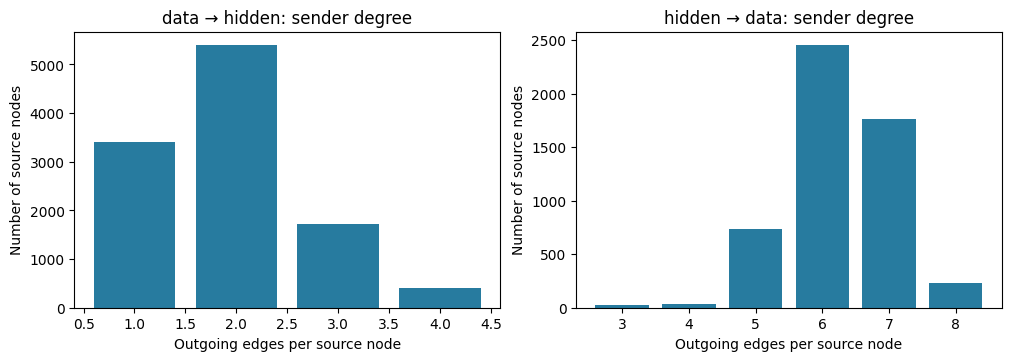

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
for ax, edge_type in zip(axes, graph.edge_types):
    degree = degrees[edge_type]["outgoing"]
    x, number = np.unique(degree, return_counts=True)
    ax.bar(x, number, color="#277b9f")
    ax.set(title=f"{edge_type[0]} → {edge_type[2]}: sender degree",
           xlabel="Outgoing edges per source node", ylabel="Number of source nodes")
plt.show()


**Result-reading exercise:** use the table and plots to explain whether every data node directly informs the encoder. Does every output data node nevertheless receive decoder information? If some inputs are unused by this encoder, what evidence would you need before deciding that the graph is adequate?

<details><summary>Discussion notes</summary>

Read the measured count of unused data senders; do not confuse it with receiver coverage. Every hidden encoder receiver has four inputs, and every data decoder receiver has three. Increasing input coverage might help, but edge counts alone cannot establish it: inspect geography, run a matched training comparison, and verify forecast errors. A sparse encoder can omit some observed locations even though the decoder covers the whole output grid.
</details>


## 4. Interpret geometric attributes and area weights

The graph holds **geometry**, not learned attention coefficients. `edge_length` is based on great-circle separation and `edge_dirs` describes relative direction. Both use `norm: unit-std` in this recipe: the saved feature numbers are normalized values, not kilometres or degrees. Their normalization is recomputed when a new graph is built.

`data.area_weight` is different again: it represents each point's spherical Voronoi cell area, scaled here to a maximum of one. Training can use these weights to balance spatial contributions to its loss. They do not describe learned information flow.


In [8]:
attribute_rows = []
for edge_type in graph.edge_types:
    for name in ("edge_length", "edge_dirs"):
        feature = graph[edge_type][name].numpy()
        assert feature.shape[0] == graph[edge_type].edge_index.shape[1]
        assert np.isfinite(feature).all()
        attribute_rows.append({"edge set": f"{edge_type[0]} → {edge_type[2]}",
                               "attribute": name, "shape": str(feature.shape),
                               "minimum": float(feature.min()), "maximum": float(feature.max()),
                               "flattened stdev": float(feature.std())})
display(pd.DataFrame(attribute_rows))
print("These statistics describe stored features after the YAML normalization policy.")


,edge set,attribute,shape,minimum,maximum,flattened stdev
0,data → hidden,edge_length,"(20992, 1)",0.441773,4.811937,0.999976
1,data → hidden,edge_dirs,"(20992, 2)",-1.414197,1.414197,0.999988
2,hidden → data,edge_length,"(32832, 1)",0.348350,5.057969,0.999985
3,hidden → data,edge_dirs,"(32832, 2)",-1.414205,1.414205,0.999992


These statistics describe stored features after the YAML normalization policy.


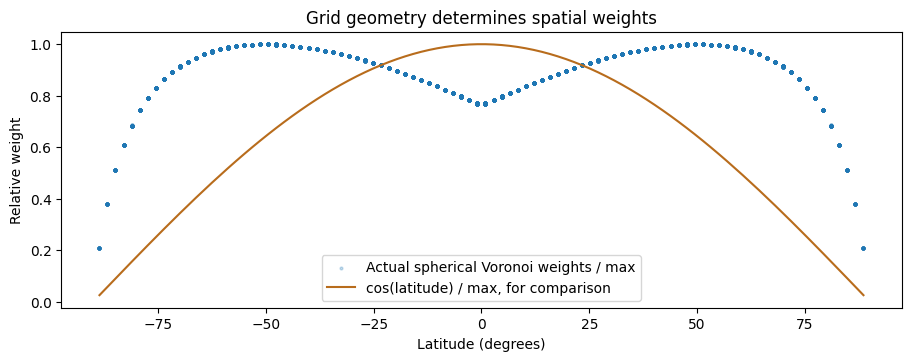

Stored weight range: 0.2075178325176239 to 1.0
For a spatial weighted mean, use sum(weight × field) / sum(weight).


In [9]:
data_xy = graph["data"].x.numpy()  # radians, in dataset point order
hidden_xy = graph["hidden"].x.numpy()
area_weights = graph["data"].area_weight.numpy().reshape(-1).astype(np.float64)
assert area_weights.shape == (expected_nodes["data"],)
assert np.isfinite(area_weights).all() and (area_weights > 0).all()
assert np.isclose(area_weights.max(), 1.0)
weights_for_mean = area_weights / area_weights.sum()
assert np.isclose(weights_for_mean.sum(), 1.0)
# Compare shapes only: cosine latitude is not our reduced-grid weighting rule.
cosine_latitude = np.cos(data_xy[:, 0])
fig, ax = plt.subplots(figsize=(9, 3.5), layout="constrained")
ax.scatter(np.rad2deg(data_xy[:, 0]), area_weights, s=4, alpha=0.25,
           label="Actual spherical Voronoi weights / max", rasterized=True)
order = np.argsort(data_xy[:, 0])
ax.plot(np.rad2deg(data_xy[order, 0]), cosine_latitude[order] / cosine_latitude.max(),
        color="#b86c1c", label="cos(latitude) / max, for comparison")
ax.set(xlabel="Latitude (degrees)", ylabel="Relative weight", title="Grid geometry determines spatial weights")
ax.legend()
plt.show()
print("Stored weight range:", area_weights.min(), "to", area_weights.max())
print("For a spatial weighted mean, use sum(weight × field) / sum(weight).")


**Predict:** why does applying cosine latitude again to these O48 area weights distort the average?

<details><summary>Discussion notes</summary>

A regular latitude–longitude grid concentrates points near the poles, which motivates cosine weighting there. A reduced Gaussian grid already changes the number of longitudes with latitude. Its actual cell areas must be derived from that geometry. Multiplying by cosine again changes the intended area measure. Normalizing positive area weights by their sum is suitable for the weighted means and RMSE in Notebook 3; the training loss's configured scalers should be inspected separately in Notebook 2.
</details>


## 5. Inspect one real spatial neighbourhood

Find the hidden node nearest Barcelona and draw the **incoming encoder arrows** from its source data points. This is a local longitude–latitude diagram, not an equal-area map. Physical distances below are computed independently from the stored radian coordinates using a spherical Earth radius of 6,371 km.

**Predict:** will K=4 imply the same maximum connection distance everywhere?


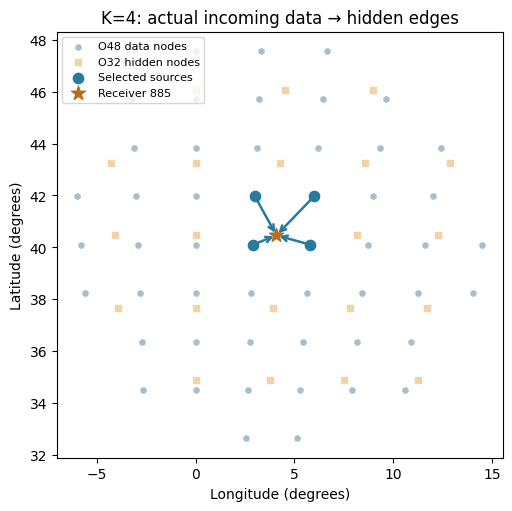

,source data id,distance to receiver (km)
0,1821,108.433983
1,1822,150.944534
2,1701,190.562561
3,1702,231.263596


In [10]:
def great_circle_km(a, b):
    """Inspect coordinate geometry only; Anemoi creates the graph in the CLI cells."""
    delta = a - b
    haversine = np.sin(delta[..., 0] / 2)**2 + np.cos(a[..., 0]) * np.cos(b[..., 0]) * np.sin(delta[..., 1] / 2)**2
    return 6371.0 * 2 * np.arcsin(np.sqrt(np.clip(haversine, 0, 1)))

centre = np.deg2rad([41.39, 2.17])
hidden_index = int(np.argmin(great_circle_km(hidden_xy, centre)))
encoder_index = graph[encoder_key].edge_index.numpy()
source_ids = encoder_index[0, encoder_index[1] == hidden_index]
assert len(source_ids) == expected_k["data", "hidden"]
data_degrees, hidden_degrees = np.rad2deg(data_xy), np.rad2deg(hidden_xy)
data_degrees[:, 1] = (data_degrees[:, 1] + 180) % 360 - 180
hidden_degrees[:, 1] = (hidden_degrees[:, 1] + 180) % 360 - 180
receiver = hidden_degrees[hidden_index]
local_data = great_circle_km(data_xy, hidden_xy[hidden_index]) < 900
local_hidden = great_circle_km(hidden_xy, hidden_xy[hidden_index]) < 900
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
ax.scatter(data_degrees[local_data, 1], data_degrees[local_data, 0], s=14, color="#a7bed0", label="O48 data nodes")
ax.scatter(hidden_degrees[local_hidden, 1], hidden_degrees[local_hidden, 0], s=25, marker="s", color="#f2d3a6", label="O32 hidden nodes")
for source in source_ids:
    point = data_degrees[source]
    ax.annotate("", xy=receiver[::-1], xytext=point[::-1], arrowprops={"arrowstyle": "->", "color": "#277b9f", "lw": 1.8})
ax.scatter(data_degrees[source_ids, 1], data_degrees[source_ids, 0], s=55, color="#277b9f", label="Selected sources")
ax.scatter(*receiver[::-1], s=110, marker="*", color="#b86c1c", label=f"Receiver {hidden_index}", zorder=5)
ax.set(xlabel="Longitude (degrees)", ylabel="Latitude (degrees)", title="K=4: actual incoming data → hidden edges")
ax.set_aspect(1 / np.cos(np.deg2rad(receiver[0])))
ax.legend(loc="upper left", fontsize=8)
plt.show()
display(pd.DataFrame({"source data id": source_ids,
                      "distance to receiver (km)": great_circle_km(data_xy[source_ids], hidden_xy[hidden_index])}).sort_values("distance to receiver (km)"))


<details><summary>Discussion notes</summary>

K fixes a count, not a physical radius. Point spacing and the relative positions of the two grids affect connection lengths. The arrows are directed toward the chosen hidden receiver; they are not the decoder's inverse graph. A straight segment in this local display visualizes endpoints; distances use spherical geometry.
</details>


## 6. Change one YAML value: K=4 → K=8

Hold the dataset, node grids, decoder K, and attribute policies fixed. Write a personal variant and run the **same native graph command**. The variant has its own file, `graphs/o48-o32-k8.pt`; keep the original for training.

**Predict before running:** which edge count doubles? Which receiver degree changes? What happens to the local source region and physical edge lengths? Does doubling encoder edges double total model cost?


In [11]:
import copy
import difflib
variant_recipe = copy.deepcopy(recipe)
variant_recipe["edges"][0]["edge_builders"][0]["num_nearest_neighbours"] = 8
variant_yaml = OUTPUT / "configs/graph-k8.yaml"
variant_yaml.parent.mkdir(parents=True, exist_ok=True)
variant_yaml.write_text(yaml.safe_dump(variant_recipe, sort_keys=False))
print("".join(difflib.unified_diff(yaml.safe_dump(recipe, sort_keys=False).splitlines(True),
                                   variant_yaml.read_text().splitlines(True),
                                   fromfile="baseline K4", tofile="personal K8")))
controlled_check = copy.deepcopy(variant_recipe)
controlled_check["edges"][0]["edge_builders"][0]["num_nearest_neighbours"] = 4
assert controlled_check == recipe  # exactly one semantic recipe change


--- baseline K4
+++ personal K8
@@ -20,7 +20,7 @@
   target_name: hidden
   edge_builders:
   - _target_: anemoi.graphs.edges.KNNEdges
-    num_nearest_neighbours: 4
+    num_nearest_neighbours: 8
   attributes: &id001
     edge_length:
       _target_: anemoi.graphs.edges.attributes.EdgeLength



In [12]:
%%bash
set -euo pipefail
anemoi-graphs create "$ANEMOI_COURSE_OUTPUT/configs/graph-k8.yaml" \
  "$ANEMOI_COURSE_OUTPUT/graphs/o48-o32-k8.pt" --overwrite \
  2>&1 | tee "$ANEMOI_COURSE_OUTPUT/graphs/create-k8.log"


2026-09-25 01:34:33 INFO Reading the dataset from /gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-an

emoi/artifacts/module-03-04-gpu-audit/assets/era5-o48-2020-2021-6h-v0.zarr.


2026-09-25 01:34:33 INFO Using environment variable ANEMOI_CONFIG_PATH to override the anemoi config

 key 'path.'


2026-09-25 01:34:34 INFO Using KNN-Edges (with 8 nearest neighbours) between data and hidden.


...

   edge_dirs │ torch.float32 │ -1.41421 │  -0.00194538 │ 1.41421 │         1
   ───

──┴───────────────┴─────────────┴

───────────────┴──────────┴───────

───────┴─────────┴──────────

🔋 Graph rea

dy.



,K4 encoder,K8 encoder
data → hidden,20992,41984
hidden → data,32832,32832


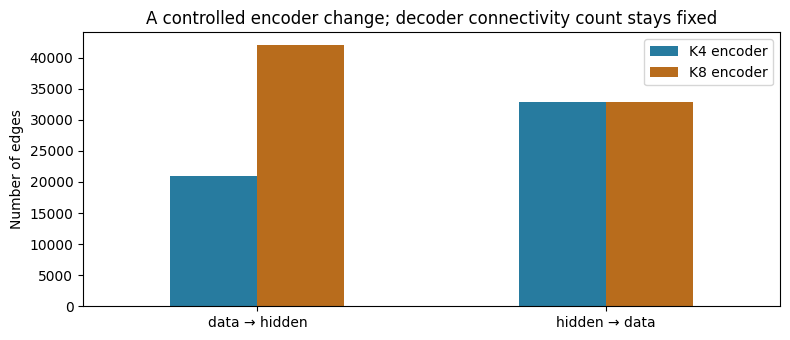

Total stored edge-count ratio: 1.39


In [13]:
variant_path = OUTPUT / "graphs/o48-o32-k8.pt"
variant = torch.load(variant_path, map_location="cpu", weights_only=False)
for name in graph.node_types:
    assert torch.equal(graph[name].x, variant[name].x)
counts = pd.DataFrame({
    "K4 encoder": {f"{s} → {t}": graph[s, relation, t].edge_index.shape[1] for s, relation, t in graph.edge_types},
    "K8 encoder": {f"{s} → {t}": variant[s, relation, t].edge_index.shape[1] for s, relation, t in variant.edge_types},
})
display(counts)
assert counts.loc["data → hidden"].iloc[1] == 2 * counts.loc["data → hidden"].iloc[0]
assert counts.loc["hidden → data"].iloc[1] == counts.loc["hidden → data"].iloc[0]
variant_receivers = np.bincount(variant[encoder_key].edge_index[1].numpy(), minlength=expected_nodes["hidden"])
assert np.all(variant_receivers == 8)
counts.plot.bar(rot=0, figsize=(8, 3.5), color=["#277b9f", "#b86c1c"])
plt.ylabel("Number of edges")
plt.title("A controlled encoder change; decoder connectivity count stays fixed")
plt.tight_layout()
plt.show()
print("Total stored edge-count ratio:", round(float(counts["K8 encoder"].sum() / counts["K4 encoder"].sum()), 3))


## 7. Interpret the change in space

Compare physical distances, not the two files' normalized edge lengths: each graph has its own `unit-std` normalization. Use the same hidden receiver and map limits for both variants. Inspect the median and maximum over **all encoder edges** as well as this local example.


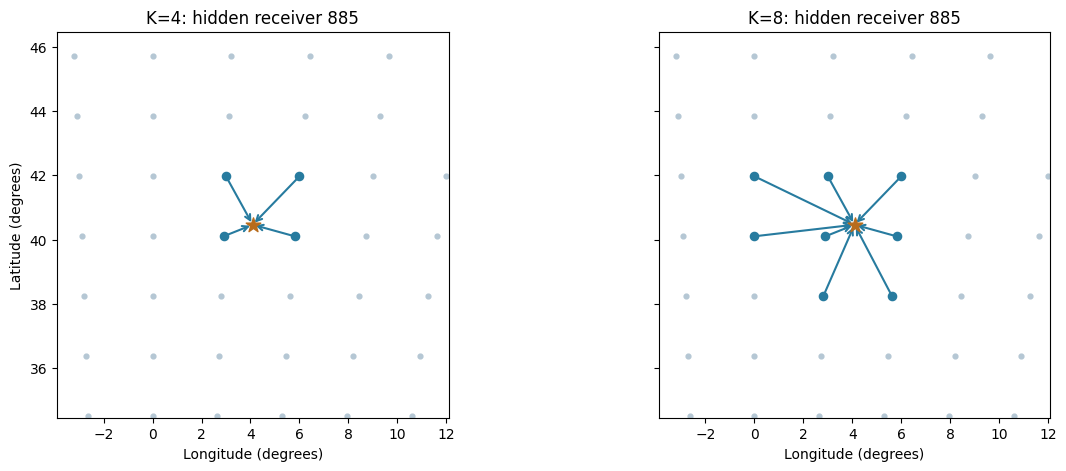

,median length (km),maximum length (km),local maximum (km)
encoder,,,
K=4,168.91,284.09,231.26
K=8,247.56,382.89,380.83


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True, layout="constrained")
distance_rows = []
for ax, candidate, label in zip(axes, (graph, variant), ("K=4", "K=8")):
    index = candidate[encoder_key].edge_index.numpy()
    sources = index[0, index[1] == hidden_index]
    distances = great_circle_km(data_xy[index[0]], hidden_xy[index[1]])
    distance_rows.append({"encoder": label, "median length (km)": float(np.median(distances)),
                          "maximum length (km)": float(distances.max()),
                          "local maximum (km)": float(great_circle_km(data_xy[sources], hidden_xy[hidden_index]).max())})
    ax.scatter(data_degrees[local_data, 1], data_degrees[local_data, 0], s=12, color="#b5c7d4")
    for source in sources:
        ax.annotate("", xy=receiver[::-1], xytext=data_degrees[source, ::-1],
                    arrowprops={"arrowstyle": "->", "color": "#277b9f", "lw": 1.5})
    ax.scatter(data_degrees[sources, 1], data_degrees[sources, 0], color="#277b9f", s=35)
    ax.scatter(*receiver[::-1], marker="*", s=120, color="#b86c1c", zorder=5)
    ax.set(title=f"{label}: hidden receiver {hidden_index}", xlabel="Longitude (degrees)",
           xlim=(receiver[1]-8, receiver[1]+8), ylim=(receiver[0]-6, receiver[0]+6))
    ax.set_aspect(1 / np.cos(np.deg2rad(receiver[0])))
axes[0].set_ylabel("Latitude (degrees)")
plt.show()
display(pd.DataFrame(distance_rows).set_index("encoder").round(2))


**Exercise (4 minutes):** explain the measured total edge-count ratio and neighbourhood change. Write a hypothesis about forecast error under K=8, then name at least four settings you would hold fixed in a training comparison. Explain why this graph experiment alone cannot test that hypothesis.

<details><summary>Discussion notes</summary>

Only encoder edges double; decoder edges and node counts stay fixed. Wider local support can provide more observations and incurs more encoder edge work, but might also change what the model learns. Edge count is not a runtime benchmark: hidden transformer processing, channel width, kernels, and memory contribute to cost. Keep training examples, splits, seed, optimizer, width, update budget, and verification dates fixed to study the graph change. No training has occurred in this notebook, so no accuracy conclusion follows from these plots.
</details>

**Optional extension:** move the inspected receiver toward a pole and repeat the distance interpretation. Update longitude wrapping/map bounds if the neighbourhood crosses the dateline; the graph itself has no dateline discontinuity. Keep the saved baseline graph unchanged.


## 8. Hand the exact baseline graph to training

Notebook 2's `system.input.graph` must resolve to the original **K=4** graph. It combines this spatial artifact with `task.timestep: 6h` and its training update budget. Changing K alone changes neither the forecast interval nor the number of optimizer steps.

Record checksums and counts so a later result can be traced to the graph you inspected. A file name alone does not prove that its contents match an experiment.


In [15]:
import hashlib
import json
from omegaconf import OmegaConf
training_yaml = OmegaConf.load(CONFIG_DIR / "forecast_6h.yaml")
training_graph = Path(training_yaml.system.input.graph)
assert training_graph.resolve() == graph_path.resolve()
manifest = {
    "training_graph": str(graph_path), "comparison_graph": str(variant_path),
    "training_graph_sha256": hashlib.sha256(graph_path.read_bytes()).hexdigest(),
    "comparison_graph_sha256": hashlib.sha256(variant_path.read_bytes()).hexdigest(),
    "recipe_sha256": hashlib.sha256(recipe_path.read_bytes()).hexdigest(),
    "node_counts": expected_nodes, "edge_counts": counts.to_dict(),
    "changed_setting": "encoder num_nearest_neighbours: 4 -> 8",
}
manifest_path = OUTPUT / "graphs/graph-comparison.json"
manifest_path.write_text(json.dumps(manifest, indent=2) + "\n")
print("Training will load:", training_graph)
print("Saved evidence:", manifest_path)
print("Forecast timestep is configured separately:", training_yaml.task.timestep)


Training will load: /gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/graphs/o48-o32.pt
Saved evidence: /gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/graphs/graph-comparison.json
Forecast timestep is configured separately: 6h


**Exit check:** distinguish a geometric edge attribute, a learned attention weight, and a spatial loss weight. Explain why a graph with the right number of points but a different point ordering is unsafe for this dataset.

<details><summary>Discussion notes</summary>

Geometric attributes describe connected locations; attention coefficients are learned model computations; area weights define spatial importance in a loss or score. Data values and graph coordinates must have the same point ordering, not merely the same length. This recipe reads coordinates directly from the dataset, which preserves that contract. Notebook 2 inspects the full model/training configuration before using the graph.
</details>

**Sources and lecture connection.** Compare the [Part 2 lecture](extra/lecture-part-2-data-to-model.ipynb) with [this graph recipe](../../configs/module-03_04/graph/o48_o32.yaml). Behaviour is checked against the pinned installed `anemoi.graphs.edges.builders.knn.KNNEdges`, `edges.attributes.EdgeLength`/`EdgeDirection`, and `nodes.attributes.area_weights.SphericalAreaWeights` implementations. The diagram is original course material; degree, weight, and neighbourhood plots use the actual generated graph.
